# **🏥 CLINICAL APPOINTMENT NO- SHOW PREDICTION**



# Dataset Description
## Dataset Source
Hospital Appointment No-Show Prediction Dataset  
Source: Kaggle  
Link: https://www.kaggle.com/datasets/miadul/hospital-appointment-no-show-prediction-dataset/data  

The dataset contains 50,000 synthetic hospital appointment records designed to predict whether a patient will miss a scheduled appointment.

Target Variable:
- no_show (0 = Show, 1 = No-Show)

------------------------------------------------------------

## Input Features and Description

1. patient_id  
   Unique identifier for each patient record.

2. age  
   Age of the patient (numerical).

3. gender  
   Gender of the patient (Male / Female).

4. city_type  
   Type of residential area (Urban / Suburban / Other).

5. distance_km  
   Distance between patient’s residence and hospital (in kilometers).

6. travel_time_min  
   Estimated travel time to hospital (in minutes).

7. appointment_day  
   Day of the week when appointment is scheduled.

8. appointment_time_slot  
   Time slot of appointment (Morning / Afternoon / Evening).

9. department  
   Medical department or specialty (Cardiology, Pediatrics, etc.).

10. waiting_days  
    Number of days between booking date and appointment date.

11. previous_appointments  
    Total number of previous hospital appointments attended.

12. previous_no_shows  
    Number of previous missed appointments.

13. diabetes  
    Binary indicator (0 = No, 1 = Yes).

14. hypertension  
    Binary indicator (0 = No, 1 = Yes).

15. chronic_disease  
    Binary indicator (0 = No, 1 = Yes).

16. sms_reminder  
    Indicates whether SMS reminder was sent (0 = No, 1 = Yes).

17. email_reminder  
    Indicates whether email reminder was sent (0 = No, 1 = Yes).

18. num_reminders  
    Total number of reminders sent to the patient.

19. employment_status  
    Employment category (Employed / Student / Other).

20. education_level  
    Education level (Primary / Secondary / Higher).

21. insurance_status  
    Insurance coverage status (Insured / Uninsured).

22. rainy_day  
    Indicates whether appointment day had rainfall (0 = No, 1 = Yes).

23. public_holiday  
    Indicates whether appointment day was a public holiday (0 = No, 1 = Yes).

------------------------------------------------------------

## Output Variable

24. no_show  
    0 → Patient attended the appointment  
    1 → Patient missed the appointment  

------------------------------------------------------------

Objective:
Build a supervised machine learning classification model to predict the probability of a patient missing their scheduled appointment using demographic, medical, behavioral, communication, and environmental features.

### 📌 **1. IMPORT LIBRARIES**

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [98]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [99]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

In [100]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix , roc_auc_score

In [101]:
plt.style.use('seaborn-v0_8-whitegrid')

plt.rcParams['figure.figsize'] = (10, 6)

plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11

primary_color = "#2E86C1"
secondary_color = "#117A65"
warning_color = "#C0392B"
neutral_color = "#7B7D7D"

sns.set_palette([primary_color, secondary_color, warning_color])

### **📌 2. LOAD DATA**

In [104]:
df = pd.read_csv("hospital_appointment_no_show_50000.csv")

### **📌 3. DATASET INFO**

In [105]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())

df.info()

Shape: (50000, 24)

Columns:
 ['patient_id', 'age', 'gender', 'city_type', 'distance_km', 'travel_time_min', 'appointment_day', 'appointment_time_slot', 'department', 'waiting_days', 'previous_appointments', 'previous_no_shows', 'diabetes', 'hypertension', 'chronic_disease', 'sms_reminder', 'email_reminder', 'num_reminders', 'employment_status', 'education_level', 'insurance_status', 'rainy_day', 'public_holiday', 'no_show']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             50000 non-null  int64  
 1   age                    50000 non-null  int64  
 2   gender                 50000 non-null  object 
 3   city_type              50000 non-null  object 
 4   distance_km            50000 non-null  float64
 5   travel_time_min        50000 non-null  float64
 6   appointment_day        50000 non-null  ob

In [106]:
df.describe()

,patient_id,age,distance_km,travel_time_min,waiting_days,previous_appointments,previous_no_shows,diabetes,hypertension,chronic_disease,sms_reminder,email_reminder,num_reminders,rainy_day,public_holiday,no_show
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,50.937700,9.987357,29.990284,6.993540,5.001520,1.247080,0.153160,0.200360,0.101660,0.703680,0.499820,1.504500,0.201600,0.099640,0.772920
std,14433.901067,19.373208,7.068633,22.423286,2.645312,2.236814,1.121203,0.360145,0.400274,0.302204,0.456638,0.500005,0.816133,0.401199,0.299522,0.418949
min,1.000000,18.000000,0.017213,0.053881,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,12500.750000,34.000000,4.818075,13.923424,5.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
50%,25000.500000,51.000000,8.357070,24.480817,7.000000,5.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,1.000000
75%,37500.250000,68.000000,13.412429,40.087056,9.000000,6.000000,2.000000,0.000000,0.000000,0.000000,1.000000,1.000000,2.000000,0.000000,0.000000,1.000000
max,50000.000000,84.000000,67.365723,232.898577,19.000000,17.000000,8.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000,1.000000


In [107]:
numerical_cols = df.select_dtypes(include=['int64','float64']).columns
categorical_cols = df.select_dtypes(include=['object','bool']).columns

print("Numerical Columns:", list(numerical_cols))
print("\nCategorical Columns:",list(categorical_cols))

Numerical Columns: ['patient_id', 'age', 'distance_km', 'travel_time_min', 'waiting_days', 'previous_appointments', 'previous_no_shows', 'diabetes', 'hypertension', 'chronic_disease', 'sms_reminder', 'email_reminder', 'num_reminders', 'rainy_day', 'public_holiday', 'no_show']

Categorical Columns: ['gender', 'city_type', 'appointment_day', 'appointment_time_slot', 'department', 'employment_status', 'education_level', 'insurance_status']


In [108]:
target = "no_show" if "no_show" in df.columns else None
target

'no_show'

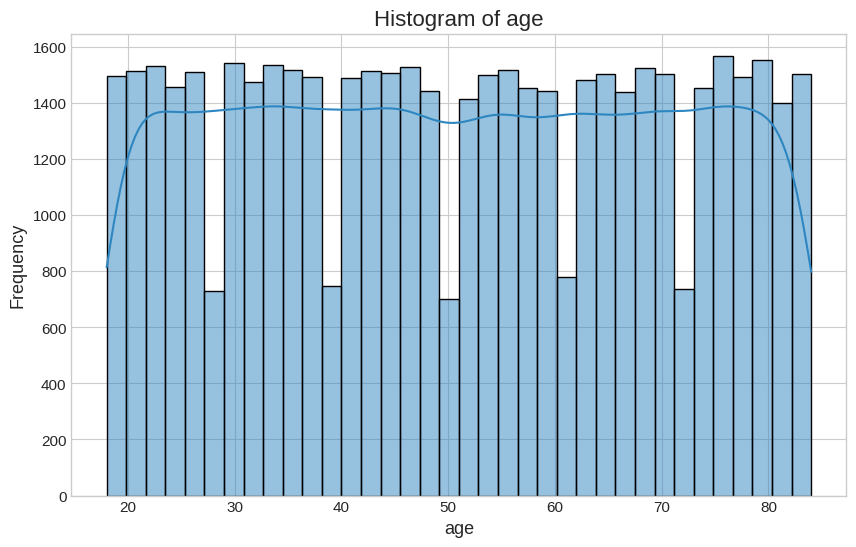

In [109]:
plt.figure()
sns.histplot(df['age'], kde=True)
plt.title(f"Histogram of {'age'}")
plt.xlabel('age')
plt.ylabel("Frequency")
plt.show()

Text(0, 0.5, 'Frequency')

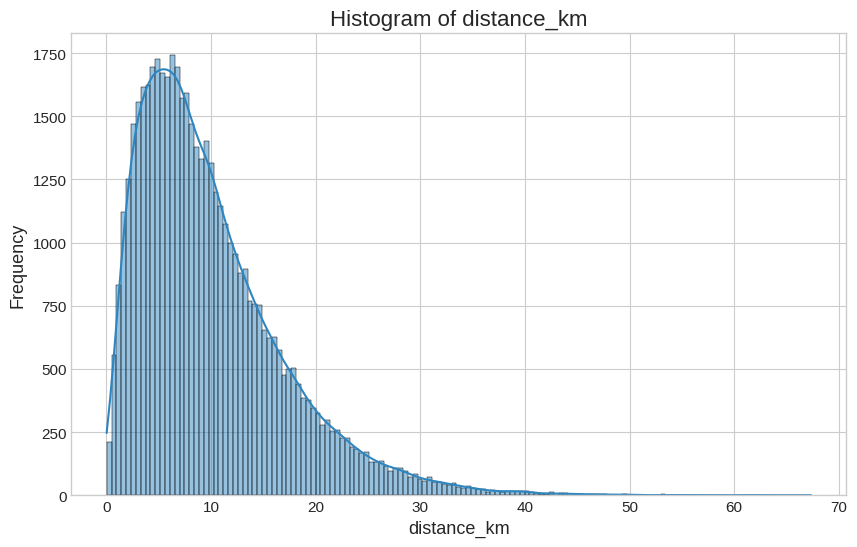

In [110]:
plt.figure()
sns.histplot(df['distance_km'], kde=True)
plt.title(f"Histogram of {'distance_km'}")
plt.xlabel('distance_km')
plt.ylabel("Frequency")

Text(0, 0.5, 'Frequency')

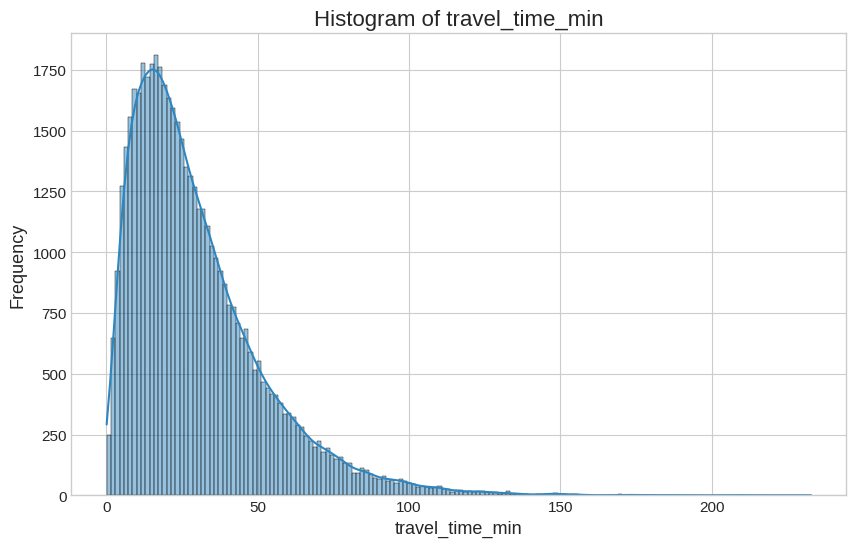

In [111]:
plt.figure()
sns.histplot(df['travel_time_min'], kde=True)
plt.title(f"Histogram of {'travel_time_min'}")
plt.xlabel('travel_time_min')
plt.ylabel("Frequency")

Text(0, 0.5, 'Frequency')

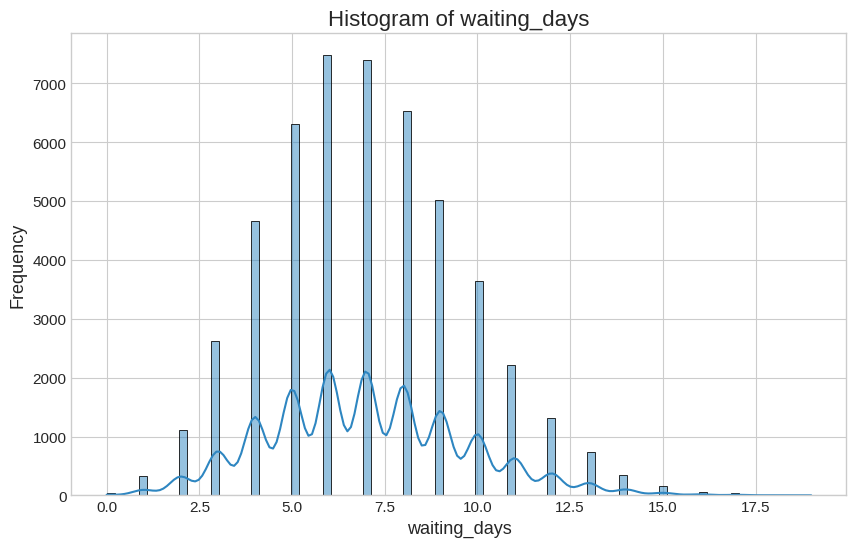

In [112]:
plt.figure()
sns.histplot(df['waiting_days'], kde=True)
plt.title(f"Histogram of {'waiting_days'}")
plt.xlabel('waiting_days')
plt.ylabel("Frequency")

Text(0, 0.5, 'Frequency')

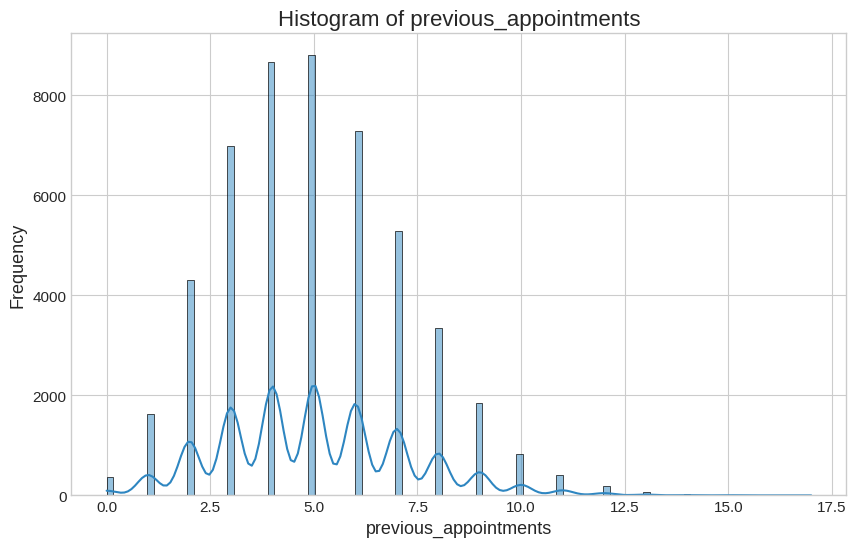

In [113]:
plt.figure()
sns.histplot(df['previous_appointments'], kde=True)
plt.title(f"Histogram of {'previous_appointments'}")
plt.xlabel('previous_appointments')
plt.ylabel("Frequency")

Text(0, 0.5, 'Frequency')

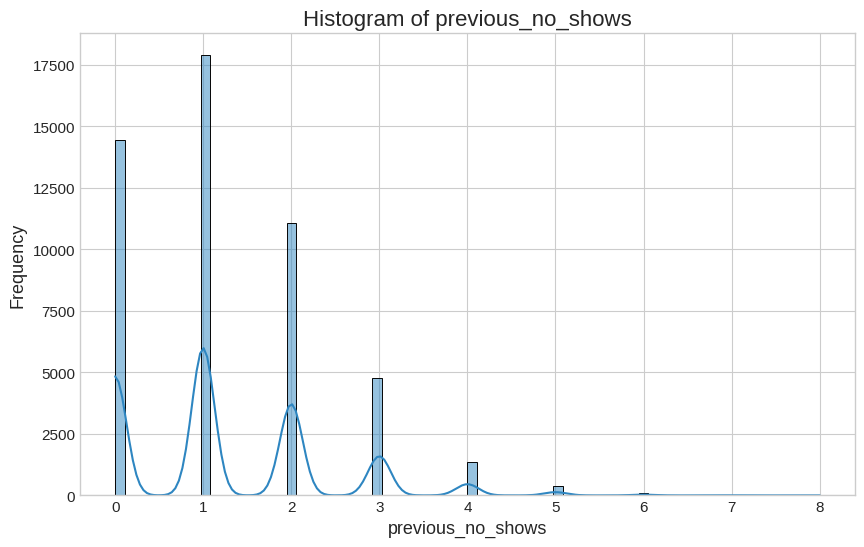

In [114]:
plt.figure()
sns.histplot(df['previous_no_shows'], kde=True)
plt.title(f"Histogram of {'previous_no_shows'}")
plt.xlabel('previous_no_shows')
plt.ylabel("Frequency")

Text(0, 0.5, 'Frequency')

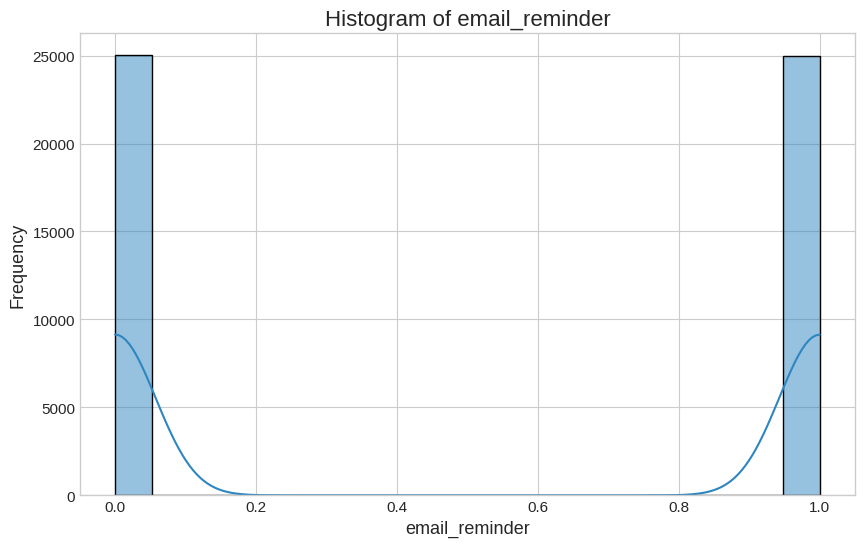

In [115]:
plt.figure()
sns.histplot(df['email_reminder'], kde=True)
plt.title(f"Histogram of {'email_reminder'}")
plt.xlabel('email_reminder')
plt.ylabel("Frequency")

Text(0, 0.5, 'Frequency')

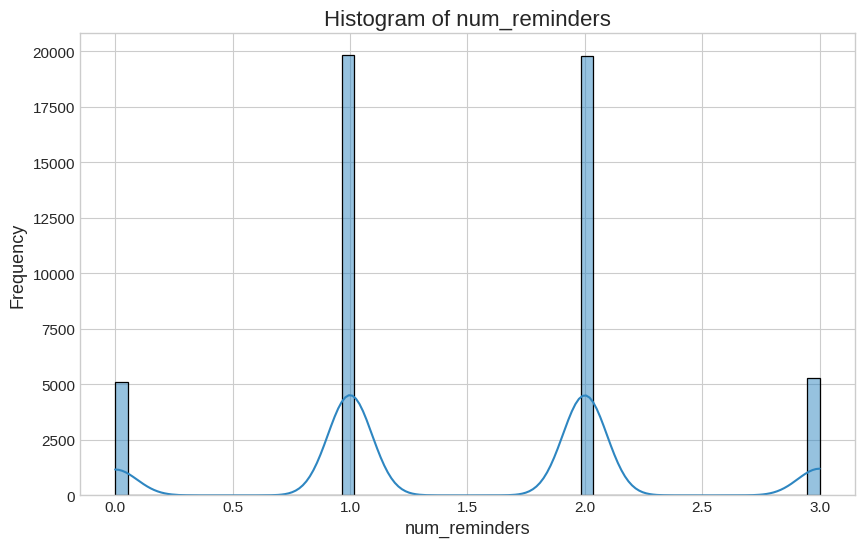

In [116]:
plt.figure()
sns.histplot(df['num_reminders'], kde=True)
plt.title(f"Histogram of {'num_reminders'}")
plt.xlabel('num_reminders')
plt.ylabel("Frequency")

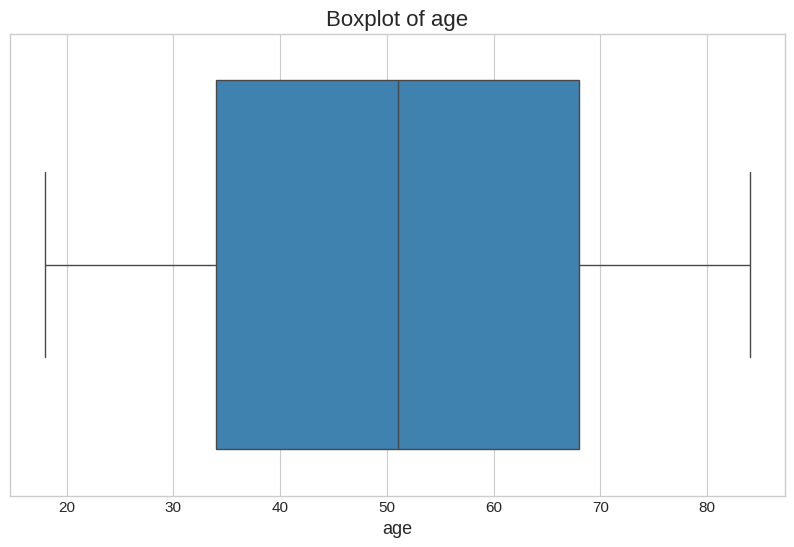

In [117]:
plt.figure()
sns.boxplot(x=df['age'])
plt.title(f"Boxplot of {'age'}")
plt.xlabel('age')
plt.show()

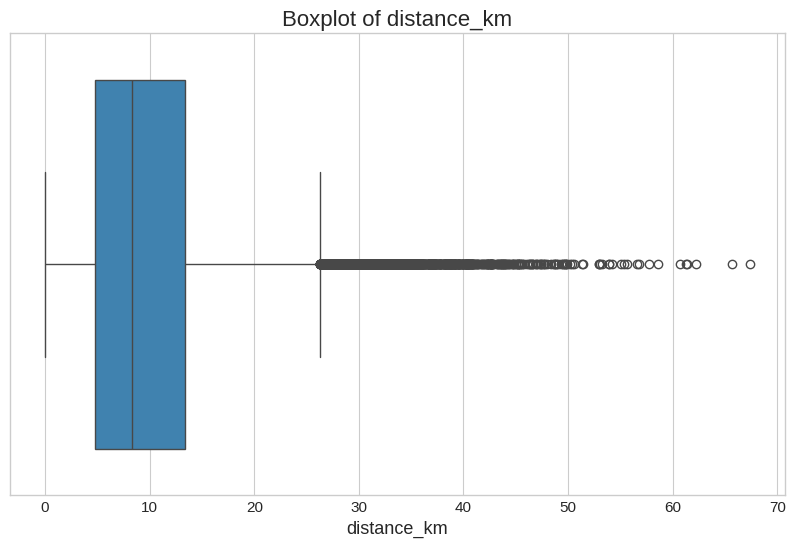

In [118]:
plt.figure()
sns.boxplot(x=df['distance_km'])
plt.title(f"Boxplot of {'distance_km'}")
plt.xlabel('distance_km')
plt.show()

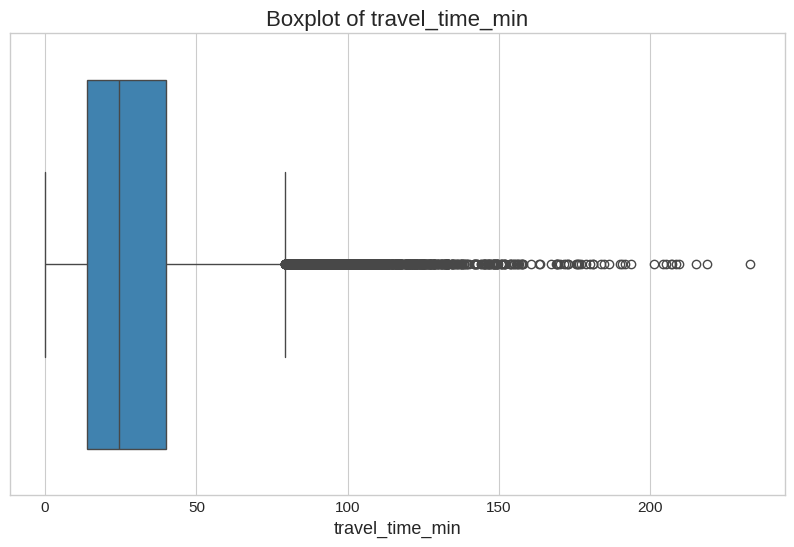

In [119]:
plt.figure()
sns.boxplot(x=df['travel_time_min'])
plt.title(f"Boxplot of {'travel_time_min'}")
plt.xlabel('travel_time_min')
plt.show()

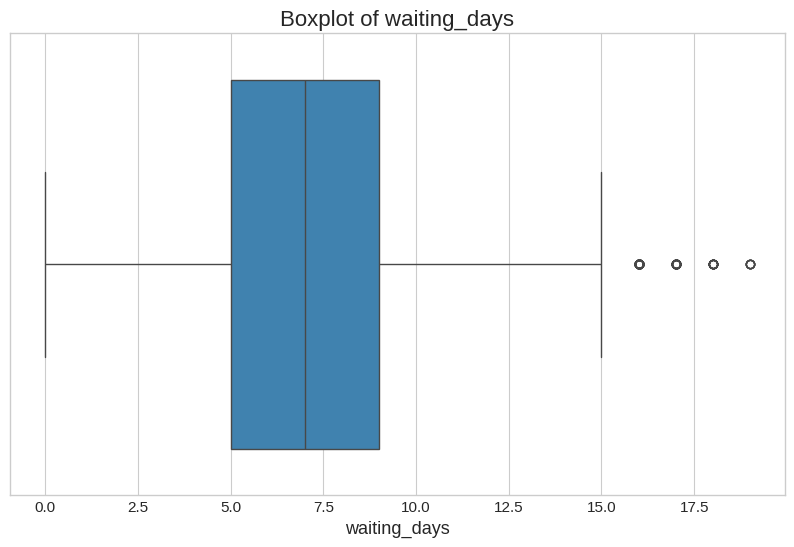

In [120]:
plt.figure()
sns.boxplot(x=df['waiting_days'])
plt.title(f"Boxplot of {'waiting_days'}")
plt.xlabel('waiting_days')
plt.show()

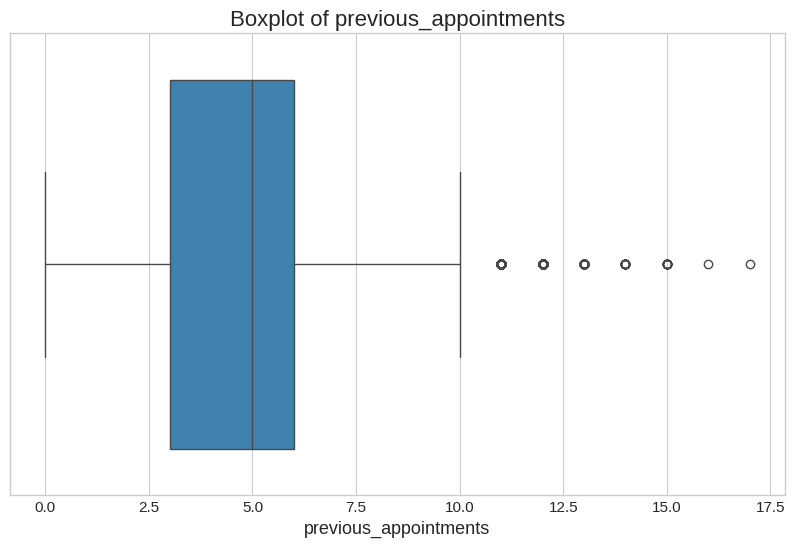

In [121]:
plt.figure()
sns.boxplot(x=df['previous_appointments'])
plt.title(f"Boxplot of {'previous_appointments'}")
plt.xlabel('previous_appointments')
plt.show()

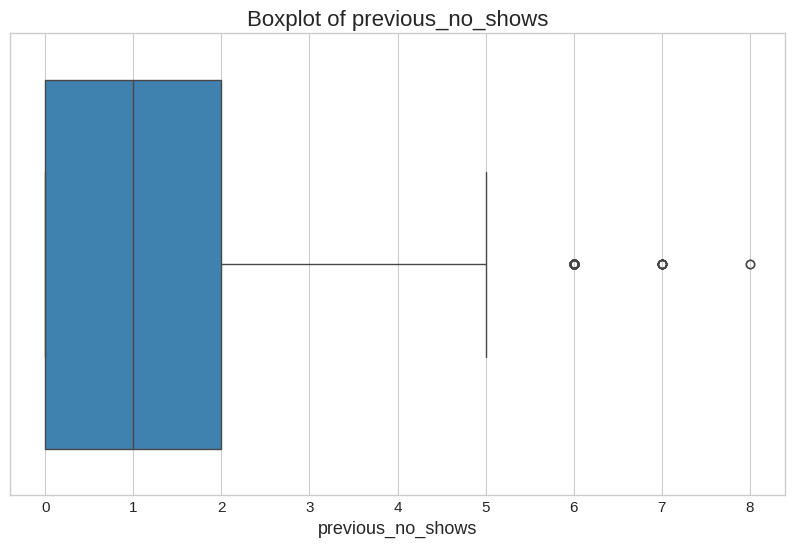

In [122]:
plt.figure()
sns.boxplot(x=df['previous_no_shows'])
plt.title(f"Boxplot of {'previous_no_shows'}")
plt.xlabel('previous_no_shows')
plt.show()

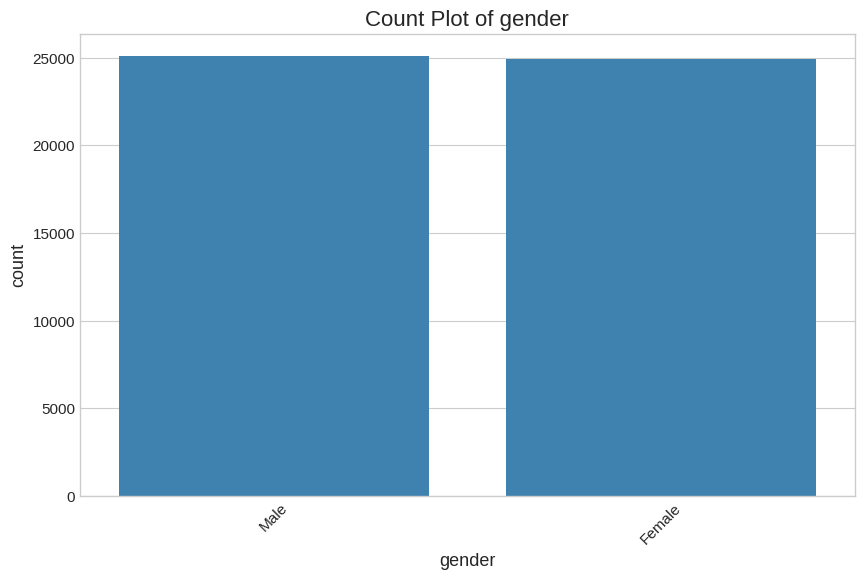

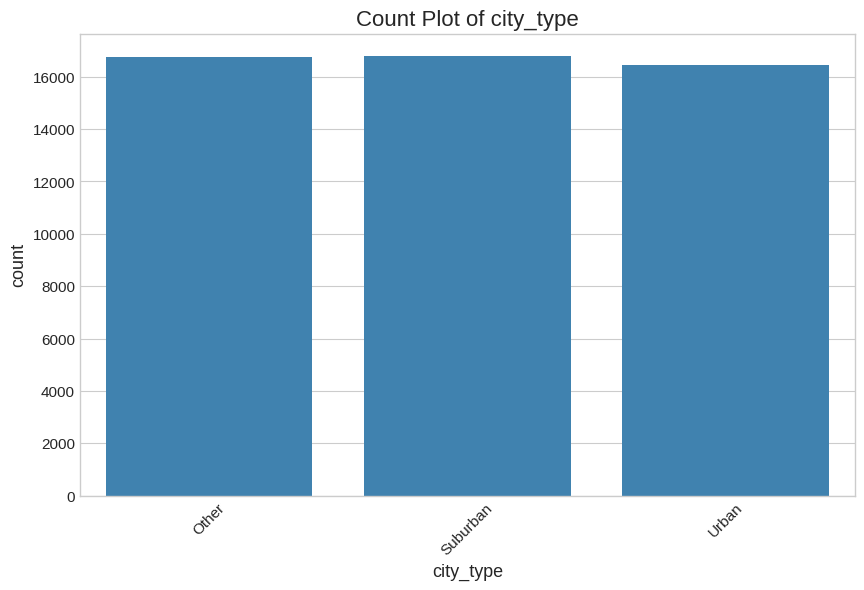

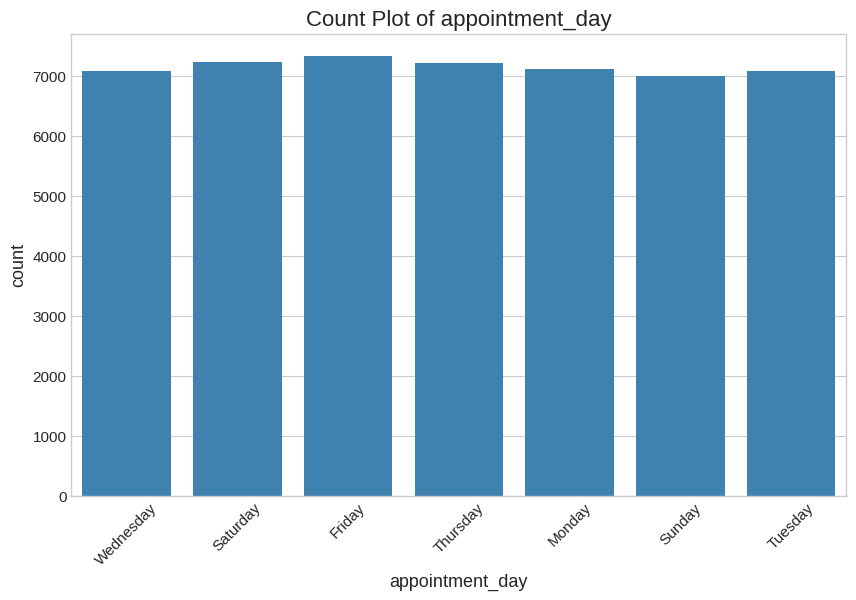

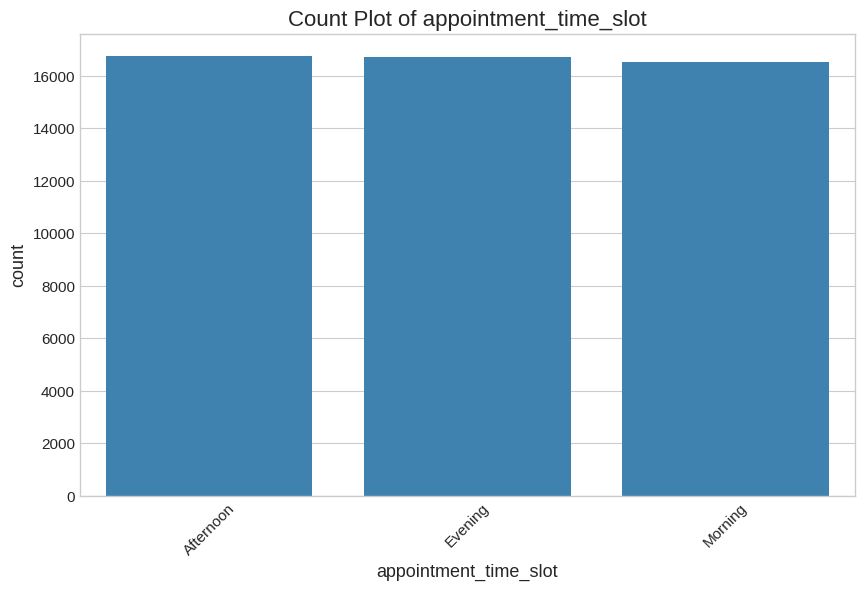

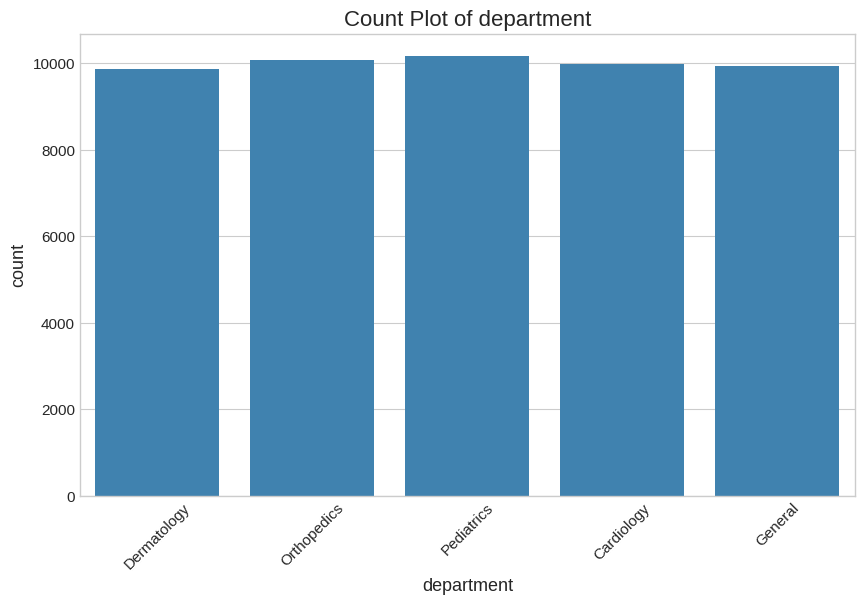

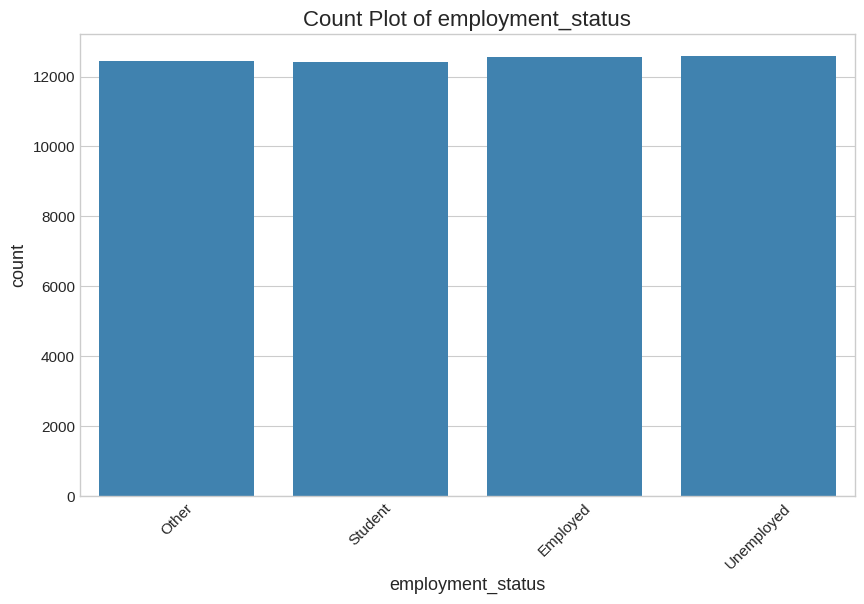

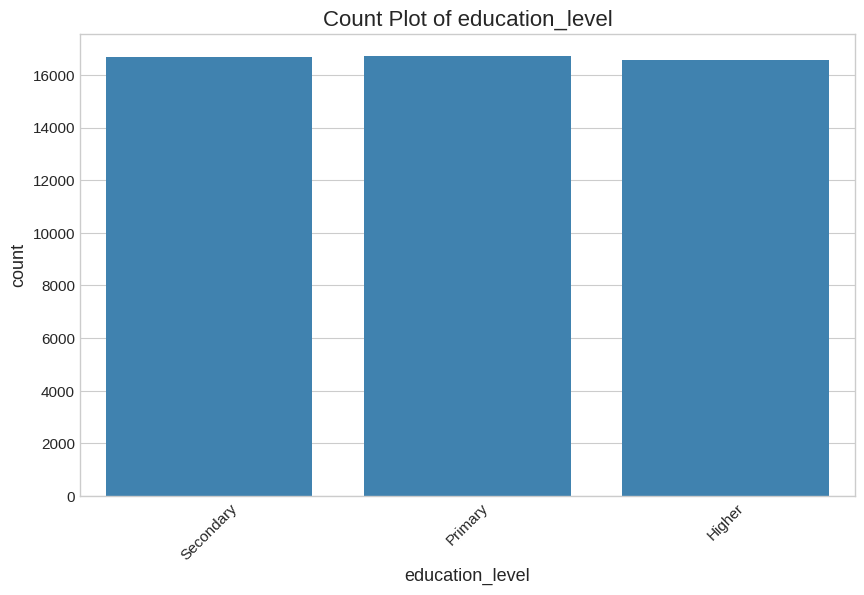

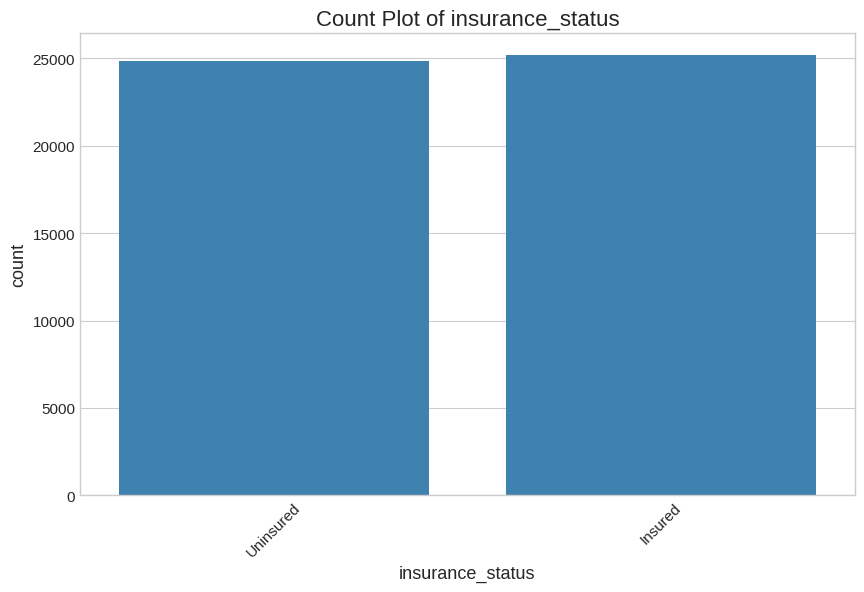

In [123]:
for col in categorical_cols:
    plt.figure()
    sns.countplot(x=df[col])
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    plt.show()

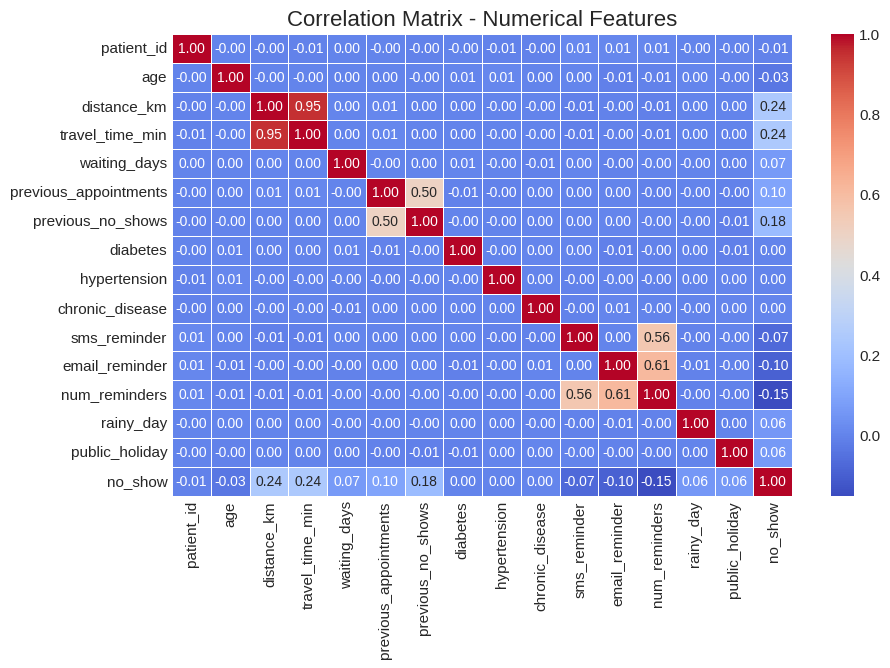

In [124]:
corr_matrix = df.corr(numeric_only=True)

sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            linewidths=0.5)

plt.title("Correlation Matrix - Numerical Features")
plt.show()

### **📌 4. FEATURE ENGINEERING**

Required Features:

Lead Time, History, Day/Time, Department

In [125]:
df.drop("patient_id", axis=1, inplace=True)

In [126]:
df.rename(columns={"waiting_days": "lead_time"}, inplace=True)

In [127]:
df["no_show_rate"] = np.where(
    df["previous_appointments"] > 0,
    df["previous_no_shows"] / df["previous_appointments"],
    0
)

In [128]:
df["is_new_patient"] = (df["previous_appointments"] == 0).astype(int)

In [129]:
df["high_risk_patient"] = (df["previous_no_shows"] >= 2).astype(int)

In [130]:
df["travel_burden"] = df["distance_km"] * df["travel_time_min"]
df["long_distance"] = (df["distance_km"] > 15).astype(int)
df["high_travel_time"] = (df["travel_time_min"] > 45).astype(int)

In [131]:
df["long_lead_time"] = (df["lead_time"] > 21).astype(int)
df["short_lead_time"] = (df["lead_time"] <= 3).astype(int)
df["same_day"] = (df["lead_time"] == 0).astype(int)
df["is_weekend"] = df["appointment_day"].isin(["Saturday", "Sunday"]).astype(int)

In [132]:
df["is_elderly"] = (df["age"] >= 65).astype(int)
df["is_young_adult"] = ((df["age"] >= 18) & (df["age"] <= 30)).astype(int)
df["has_chronic_condition"] = (
    (df["diabetes"] == 1) | (df["hypertension"] == 1) | (df["chronic_disease"] == 1)
).astype(int)
df["multiple_chronic"] = (
    df["diabetes"] + df["hypertension"] + df["chronic_disease"] >= 2
).astype(int)

In [133]:
df["got_reminder"] = ((df["sms_reminder"] == 1) | (df["email_reminder"] == 1)).astype(int)
df["multiple_reminders"] = (df["num_reminders"] >= 2).astype(int)
df["is_uninsured"] = (df["insurance_status"] == "Uninsured").astype(int)
df["is_unemployed"] = (df["employment_status"] == "Unemployed").astype(int)
df["risk_distance"] = df["high_risk_patient"] * df["long_distance"]
df["uninsured_distance"] = df["is_uninsured"] * df["long_distance"]
df["young_long_wait"] = df["is_young_adult"] * df["long_lead_time"]
df["rain_distance"] = df["rainy_day"] * df["long_distance"]

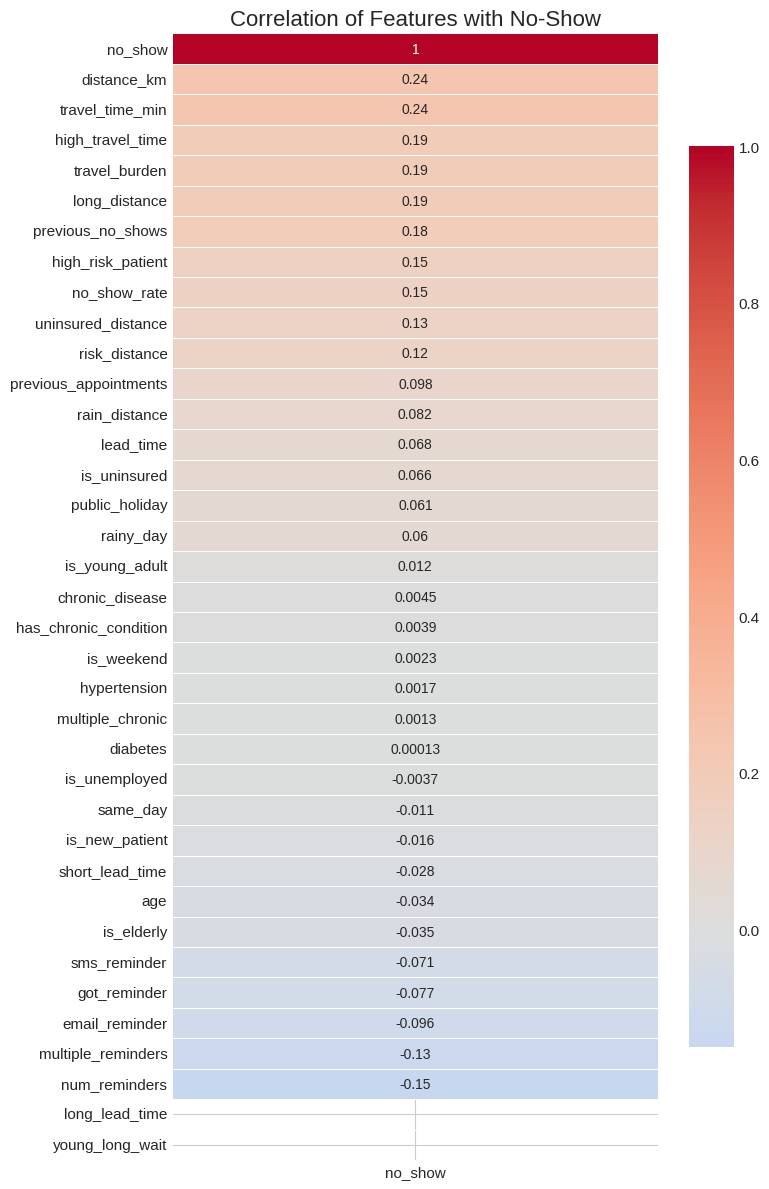

In [186]:
corr_target = df.corr(numeric_only=True)[["no_show"]].sort_values(by="no_show", ascending=False)

plt.figure(figsize=(8, 12))

sns.heatmap(
    corr_target,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation of Features with No-Show", fontsize=16)
plt.tight_layout()
plt.show()

### **📌 5. DEFINE FEATURES AND TARGET**

In [135]:
X = df.drop("no_show", axis=1)
y = df["no_show"]

### **📌 6. SPLIT DATA**

In [136]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42 , stratify=y
)

### **📌 7. PREPROCESSING PIPELINE**

In [137]:
numerical_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X_train.select_dtypes(include=["object"]).columns

In [138]:
print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: Index(['age', 'distance_km', 'travel_time_min', 'lead_time',
       'previous_appointments', 'previous_no_shows', 'diabetes',
       'hypertension', 'chronic_disease', 'sms_reminder', 'email_reminder',
       'num_reminders', 'rainy_day', 'public_holiday', 'no_show_rate',
       'is_new_patient', 'high_risk_patient', 'travel_burden', 'long_distance',
       'high_travel_time', 'long_lead_time', 'short_lead_time', 'same_day',
       'is_weekend', 'is_elderly', 'is_young_adult', 'has_chronic_condition',
       'multiple_chronic', 'got_reminder', 'multiple_reminders',
       'is_uninsured', 'is_unemployed', 'risk_distance', 'uninsured_distance',
       'young_long_wait', 'rain_distance'],
      dtype='object')
Categorical Columns: Index(['gender', 'city_type', 'appointment_day', 'appointment_time_slot',
       'department', 'employment_status', 'education_level',
       'insurance_status'],
      dtype='object')


###  🔹 **7.1. Handle Missing Values**

In [139]:
X_train.isnull().sum()

,0
age,0
gender,0
city_type,0
distance_km,0
travel_time_min,0
appointment_day,0
appointment_time_slot,0
department,0
lead_time,0
previous_appointments,0


In [140]:
X_test.isnull().sum()

,0
age,0
gender,0
city_type,0
distance_km,0
travel_time_min,0
appointment_day,0
appointment_time_slot,0
department,0
lead_time,0
previous_appointments,0


In [141]:
for col in numerical_cols:
    median_value = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_value)
    X_test[col] = X_test[col].fillna(median_value)

for col in categorical_cols:
    mode_value = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(mode_value)
    X_test[col] = X_test[col].fillna(mode_value)

###🔹 **7.2. Encoding Categorical Variables**

We use One-Hot Encoding for all categorical variables.

Why not Label Encoding?

Because:
Logistic Regression assumes numeric order.

In [142]:
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

###🔹 **7.3. StandardScaler**

In [143]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### **📌 8. MODEL TRAINING**

###🔹 **8.1. LOGISTIC REGRESSION**

In [144]:
results = []

In [145]:
logistic_model = LogisticRegression(
    max_iter=1000,
    C=0.1,
    class_weight='balanced',
    random_state=42
)

logistic_model.fit(X_train, y_train)

LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000,
                   random_state=42)

In [146]:
y_pred_log = logistic_model.predict(X_test)
y_prob_log = logistic_model.predict_proba(X_test)[:, 1]

In [147]:
acc_log = accuracy_score(y_test, y_pred_log)
prec_log = precision_score(y_test, y_pred_log)
rec_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)
auc_log = roc_auc_score(y_test, y_prob_log)

print("Logistic Regression Results")
print("Accuracy :", acc_log)
print("Precision:", prec_log)
print("Recall   :", rec_log)
print("F1 Score :", f1_log)
print("ROC-AUC  :", auc_log)

Logistic Regression Results
Accuracy : 0.6755
Precision: 0.8912739965095986
Recall   : 0.6607581834648726
F1 Score : 0.7588973920796493
ROC-AUC  : 0.76381825578823


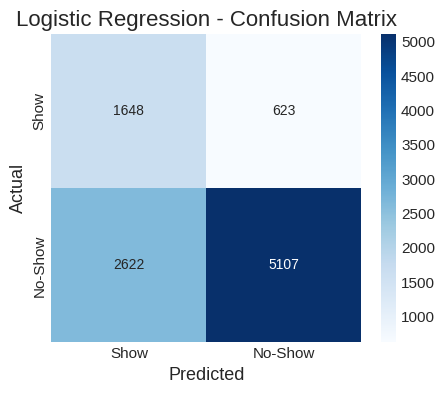

In [148]:
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5,4))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Show", "No-Show"],
            yticklabels=["Show", "No-Show"])

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [149]:
results.append({
    "Model": "Logistic Regression",
    "Accuracy": acc_log,
    "Precision": prec_log,
    "Recall": rec_log,
    "F1": f1_log,
    "ROC-AUC": auc_log
})

###🔹 **8.2. DECISION TREE**

In [150]:
decision_tree_model = DecisionTreeClassifier(max_depth=10,
    min_samples_split=30,
    min_samples_leaf=15,
    class_weight='balanced',
    random_state=42
)
decision_tree_model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=15, min_samples_split=30,
                       random_state=42)

In [151]:
y_pred_tree = decision_tree_model.predict(X_test)
y_prob_tree = decision_tree_model.predict_proba(X_test)[:, 1]

In [152]:
acc_tree = accuracy_score(y_test, y_pred_tree)
prec_tree = precision_score(y_test, y_pred_tree)
rec_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)
auc_tree = roc_auc_score(y_test, y_prob_tree)

print("Decision Tree Results")
print("Accuracy :", acc_tree)
print("Precision:", prec_tree)
print("Recall   :", rec_tree)
print("F1 Score :", f1_tree)
print("ROC-AUC  :", auc_tree)

Decision Tree Results
Accuracy : 0.6494
Precision: 0.8732543751104825
Recall   : 0.639151248544443
F1 Score : 0.7380845659644405
ROC-AUC  : 0.7149850913476491


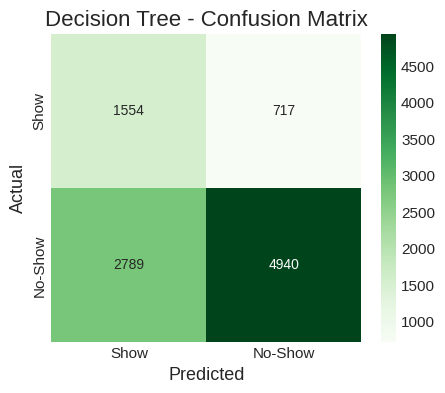

In [153]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(5,4))
sns.heatmap(cm_tree, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Show", "No-Show"],
            yticklabels=["Show", "No-Show"])

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [154]:
results.append({
    "Model": "Decision Tree",
    "Accuracy": acc_tree,
    "Precision": prec_tree,
    "Recall": rec_tree,
    "F1": f1_tree,
    "ROC-AUC": auc_tree
})

###🔹 **8.3. RANDOM FOREST**

In [155]:
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
random_forest_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_leaf=10, min_samples_split=20,
                       n_estimators=200, n_jobs=-1, random_state=42)

In [156]:
y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

In [157]:
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results")
print("Accuracy :", acc_rf)
print("Precision:", prec_rf)
print("Recall   :", rec_rf)
print("F1 Score :", f1_rf)
print("ROC-AUC  :", auc_rf)

Random Forest Results
Accuracy : 0.7174
Precision: 0.8703731681522888
Recall   : 0.7453745633329021
F1 Score : 0.8030387510454419
ROC-AUC  : 0.7549566989064103


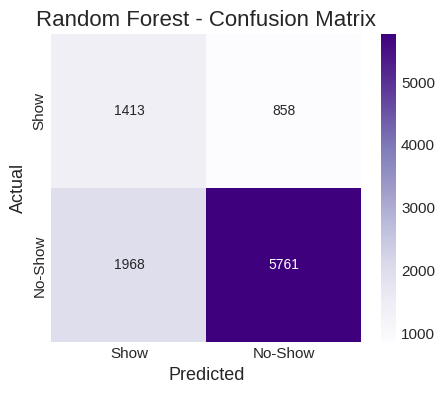

In [158]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Show", "No-Show"],
            yticklabels=["Show", "No-Show"])

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [159]:
results.append({
    "Model": "Random Forest",
    "Accuracy": acc_rf,
    "Precision": prec_rf,
    "Recall": rec_rf,
    "F1": f1_rf,
    "ROC-AUC": auc_rf
})

###🔹 **8.4. XGBoost Classifier**

In [160]:
xgboost_model =  XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

xgboost_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [161]:
y_pred_xg = xgboost_model.predict(X_test)
y_prob_xg = xgboost_model.predict_proba(X_test)[:, 1]

In [162]:
acc_xg = accuracy_score(y_test, y_pred_xg)
prec_xg = precision_score(y_test, y_pred_xg)
rec_xg = recall_score(y_test, y_pred_xg)
f1_xg = f1_score(y_test, y_pred_xg)
auc_xg = roc_auc_score(y_test, y_prob_xg)

print("Random Forest Results")
print("Accuracy :", acc_xg)
print("Precision:", prec_xg)
print("Recall   :", rec_xg)
print("F1 Score :", f1_xg)
print("ROC-AUC  :", auc_xg)

Random Forest Results
Accuracy : 0.7799
Precision: 0.8052794345040866
Recall   : 0.9433303144003106
F1 Score : 0.8688553893821128
ROC-AUC  : 0.7517027574155997


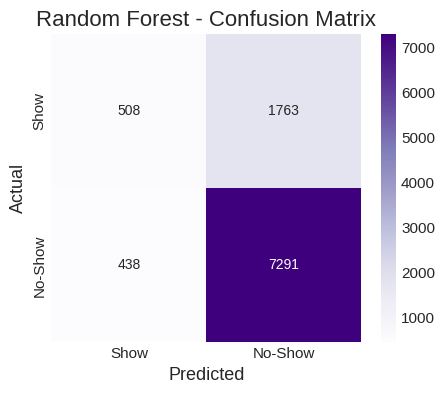

In [163]:
cm_xg = confusion_matrix(y_test, y_pred_xg)

plt.figure(figsize=(5,4))
sns.heatmap(cm_xg, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Show", "No-Show"],
            yticklabels=["Show", "No-Show"])

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [164]:
results.append({
    "Model": "XGBoost",
    "Accuracy": acc_xg,
    "Precision": prec_xg,
    "Recall": rec_xg,
    "F1": f1_xg,
    "ROC-AUC": auc_xg
})

### **📌 9. COMPARE ALL MODELS**


MODEL COMPARISON
              Model  Accuracy  Precision   Recall       F1  ROC-AUC
Logistic Regression    0.6755   0.891274 0.660758 0.758897 0.763818
      Random Forest    0.7174   0.870373 0.745375 0.803039 0.754957
            XGBoost    0.7799   0.805279 0.943330 0.868855 0.751703
      Decision Tree    0.6494   0.873254 0.639151 0.738085 0.714985


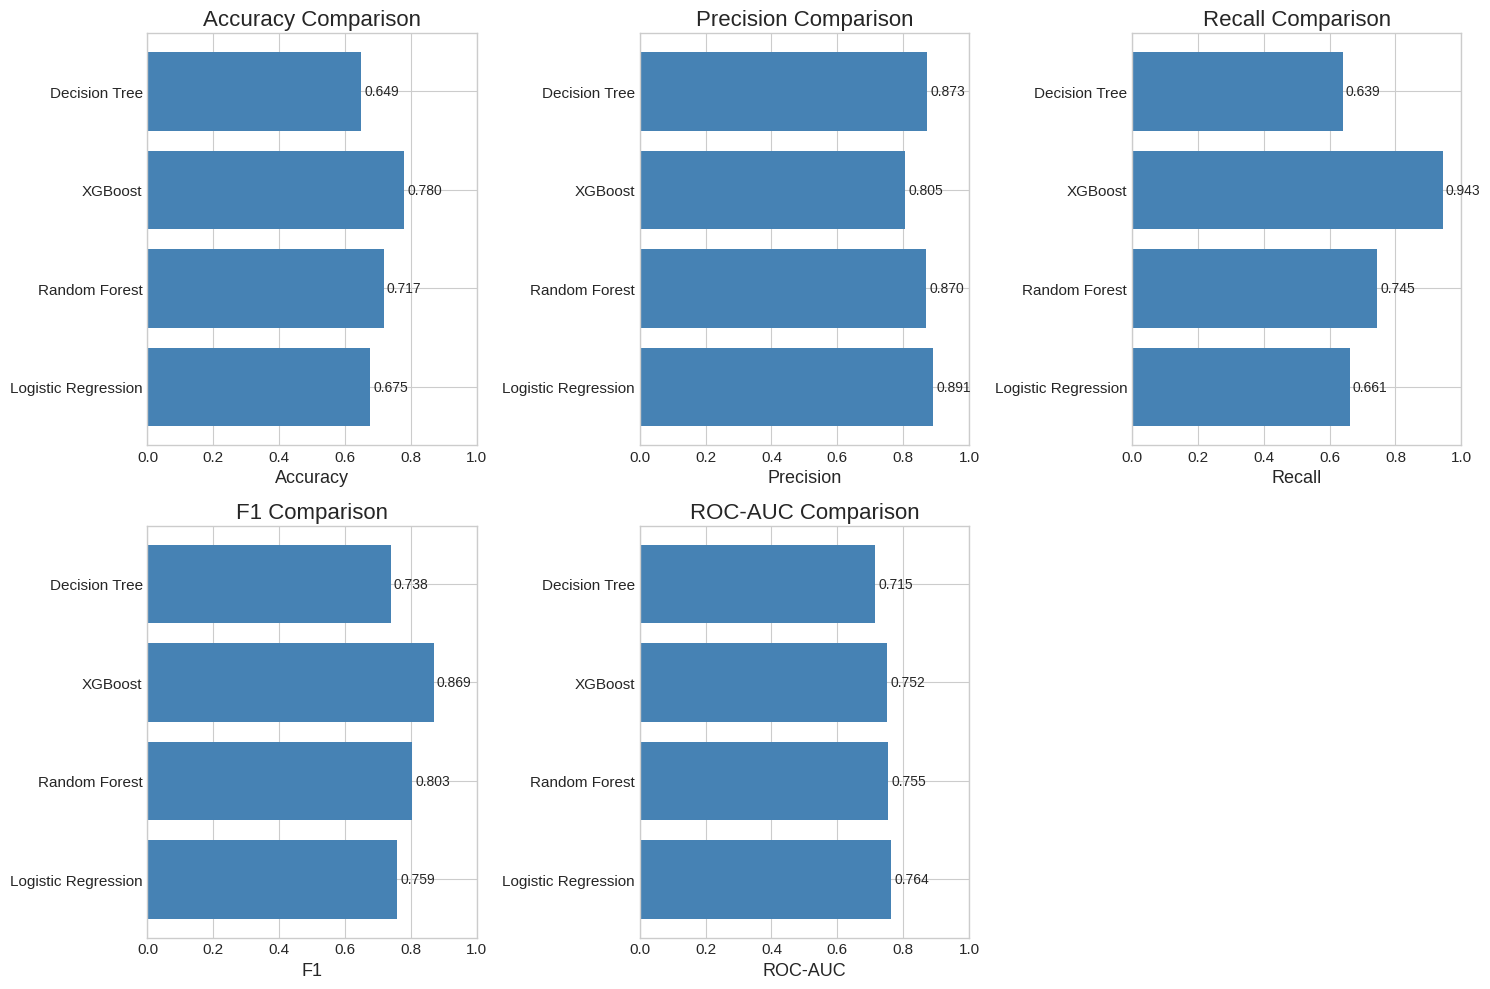


FEATURE IMPORTANCE ANALYSIS

Top 15 Most Important Features:
               Feature  Importance
     previous_no_shows    0.094305
         travel_burden    0.081585
         num_reminders    0.075587
        public_holiday    0.049846
       travel_time_min    0.039319
          no_show_rate    0.039058
             rainy_day    0.037477
          is_uninsured    0.035734
             lead_time    0.020279
        email_reminder    0.018526
           distance_km    0.018331
    uninsured_distance    0.016652
appointment_day_Sunday    0.016453
                   age    0.016354
         long_distance    0.016268


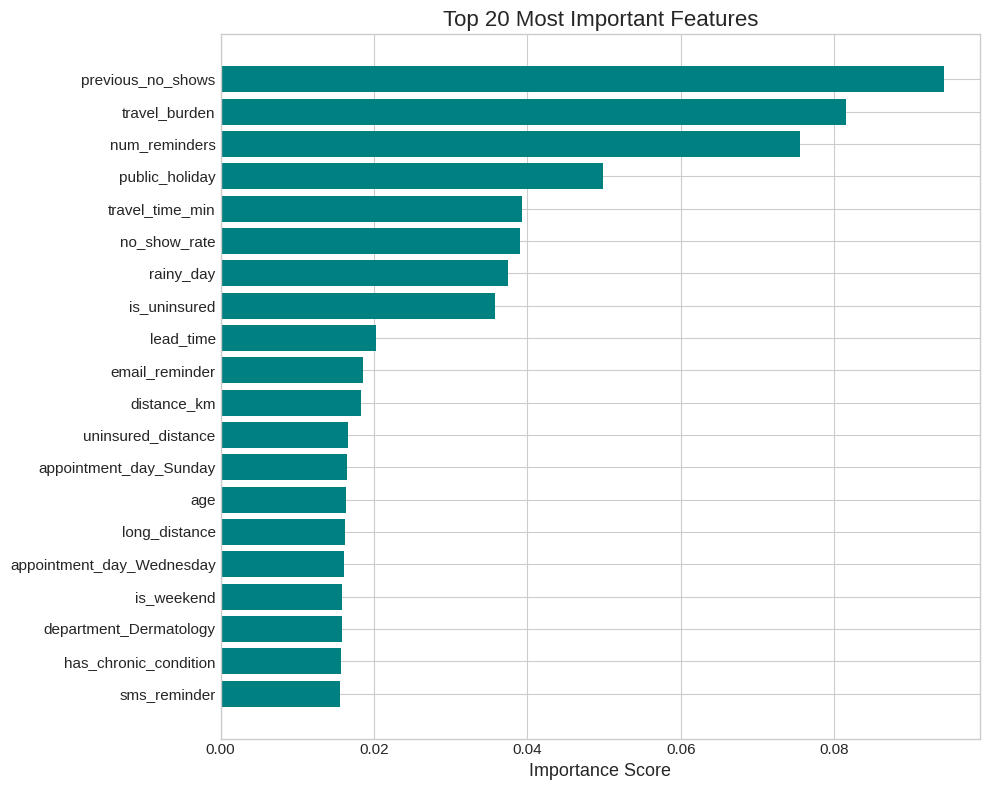

In [188]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("ROC-AUC", ascending=False)

print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)
print(results_df.to_string(index=False))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']

for idx, metric in enumerate(metrics):
    row = idx // 3
    col = idx % 3

    axes[row, col].barh(results_df['Model'], results_df[metric], color='steelblue')
    axes[row, col].set_xlabel(metric)
    axes[row, col].set_xlim([0, 1])
    axes[row, col].set_title(f'{metric} Comparison')

    for i, v in enumerate(results_df[metric]):
        axes[row, col].text(v + 0.01, i, f'{v:.3f}', va='center')


fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*70)


feature_names = pd.get_dummies(
    df.drop("no_show", axis=1),
    columns=df.drop("no_show", axis=1).select_dtypes(include=['object']).columns,
    drop_first=True
).columns

best_model = xgboost_model

importances = best_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)


print("\nTop 15 Most Important Features:")
print(feature_importance_df.head(15).to_string(index=False))


plt.figure(figsize=(10, 8))
top_20 = feature_importance_df.head(20)
plt.barh(range(len(top_20)), top_20['Importance'], color='teal')
plt.yticks(range(len(top_20)), top_20['Feature'])
plt.xlabel('Importance Score')
plt.title('Top 20 Most Important Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### **📌 STEP 10 — MODEL OPTIMIZATION & DECISION STRATEGY**

### **🔹 10.1 Select Best Model (XGBoost)**

In [174]:
best_model = xgboost_model
y_prob = y_prob_xg

### **🔹 10.2 Threshold Optimization**

In [175]:
from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, thresholds = precision_recall_curve(y_test, y_prob)

f1_scores = 2 * (precision_curve * recall_curve) / (precision_curve + recall_curve + 1e-10)

optimal_idx = np.argmax(f1_scores[:-1])
optimal_threshold = thresholds[optimal_idx]

print("Optimal Threshold:", optimal_threshold)

Optimal Threshold: 0.39516616


### **🔹 10.3 Evaluate with Optimized Threshold**

In [189]:
y_pred_optimal = (y_prob >= optimal_threshold).astype(int)

print("\nAfter Threshold Optimization")
print("Accuracy :", accuracy_score(y_test, y_pred_optimal))
print("Precision:", precision_score(y_test, y_pred_optimal))
print("Recall   :", recall_score(y_test, y_pred_optimal))
print("F1 Score :", f1_score(y_test, y_pred_optimal))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))


After Threshold Optimization
Accuracy : 0.7831
Precision: 0.7888011635154789
Recall   : 0.9824039332384525
F1 Score : 0.8750216076058772
ROC-AUC  : 0.7517027574155997


###🔹 **10.4 Feature Importance Analysis**

In [181]:
preprocessor = xgb_pipeline.named_steps["preprocessing"]
encoded_feature_names = preprocessor.get_feature_names_out()
importances = xgb_pipeline.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": encoded_feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print(importance_df.head(10))

                    Feature  Importance
18       num__long_distance    0.222868
16   num__high_risk_patient    0.099927
19    num__high_travel_time    0.089695
29  num__multiple_reminders    0.055123
5    num__previous_no_shows    0.049272
17       num__travel_burden    0.044134
11       num__num_reminders    0.035090
2      num__travel_time_min    0.030167
13      num__public_holiday    0.025049
12           num__rainy_day    0.021089


# **FINAL OPTIMIZED MODEL SUMMARY**

In [182]:
print(f"Chosen Model: XGBoost")
print(f"Optimized Threshold: {optimal_threshold:.2f}")
print(f"Final ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
print("High recall ensures most no-shows are detected.")
print("Threshold tuning improves precision to reduce unnecessary alerts.")

Chosen Model: XGBoost
Optimized Threshold: 0.40
Final ROC-AUC: 0.7517
High recall ensures most no-shows are detected.
Threshold tuning improves precision to reduce unnecessary alerts.
